# Life Expectancy — Part 3: Advanced Modeling


## Rebuild Part 2 Data Setup

We reload `cleaned_data.csv` and rebuild the exact same `X`, `y_reg`, `y_clf`, train/test split, and scaling from Part 2 (same `random_state=42`) so results are directly comparable.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.base import clone

sns.set_theme(style="whitegrid", palette="muted")

df = pd.read_csv("cleaned_data.csv")

TARGET = "Life expectancy"
X = df.drop(columns=[TARGET, "Country"]).copy()
y_reg = df[TARGET].copy()
y_clf = (y_reg > y_reg.median()).astype(int)

status_map = {"Developing": 0, "Developed": 1}
X["Status"] = X["Status"].map(status_map)

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42
)

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"X_train: {X_train.shape}   X_test: {X_test.shape}")

X_train: (2350, 20)   X_test: (588, 20)


## Task 1 – Decision Tree Baseline (Unconstrained)

In [2]:
dt_unconstrained = DecisionTreeClassifier(random_state=42)
dt_unconstrained.fit(X_train_scaled, y_clf_train)

train_acc_uc = accuracy_score(y_clf_train, dt_unconstrained.predict(X_train_scaled))
test_acc_uc  = accuracy_score(y_clf_test, dt_unconstrained.predict(X_test_scaled))

print(f"Training accuracy: {train_acc_uc:.4f}")
print(f"Test accuracy    : {test_acc_uc:.4f}")
print(f"Train-test gap   : {train_acc_uc - test_acc_uc:.4f}")

Training accuracy: 1.0000
Test accuracy    : 0.9286
Train-test gap   : 0.0714


## Task 2 – Controlled Decision Tree (max_depth=5, min_samples_split=20)

In [3]:
dt_controlled = DecisionTreeClassifier(max_depth=5, min_samples_split=20, random_state=42)
dt_controlled.fit(X_train_scaled, y_clf_train)

train_acc_c = accuracy_score(y_clf_train, dt_controlled.predict(X_train_scaled))
test_acc_c  = accuracy_score(y_clf_test, dt_controlled.predict(X_test_scaled))

print(f"Training accuracy: {train_acc_c:.4f}")
print(f"Test accuracy    : {test_acc_c:.4f}")
print(f"Train-test gap   : {train_acc_c - test_acc_c:.4f}")

print(f"\nComparison:")
print(f"  Unconstrained gap: {train_acc_uc - test_acc_uc:.4f}")
print(f"  Controlled gap   : {train_acc_c - test_acc_c:.4f}")

Training accuracy: 0.9400
Test accuracy    : 0.9218
Train-test gap   : 0.0182

Comparison:
  Unconstrained gap: 0.0714
  Controlled gap   : 0.0182


## Task 3 – Gini vs Entropy (max_depth=5)

In [4]:
dt_gini = DecisionTreeClassifier(max_depth=5, criterion="gini", random_state=42)
dt_gini.fit(X_train_scaled, y_clf_train)
test_acc_gini = accuracy_score(y_clf_test, dt_gini.predict(X_test_scaled))

dt_entropy = DecisionTreeClassifier(max_depth=5, criterion="entropy", random_state=42)
dt_entropy.fit(X_train_scaled, y_clf_train)
test_acc_entropy = accuracy_score(y_clf_test, dt_entropy.predict(X_test_scaled))

print(f"Gini    test accuracy: {test_acc_gini:.4f}")
print(f"Entropy test accuracy: {test_acc_entropy:.4f}")

Gini    test accuracy: 0.9218
Entropy test accuracy: 0.9014


## Task 4 – Random Forest

In [5]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train_scaled, y_clf_train)

rf_train_acc = accuracy_score(y_clf_train, rf.predict(X_train_scaled))
rf_test_acc  = accuracy_score(y_clf_test, rf.predict(X_test_scaled))
rf_proba     = rf.predict_proba(X_test_scaled)[:, 1]
rf_auc       = roc_auc_score(y_clf_test, rf_proba)

print(f"Training accuracy: {rf_train_acc:.4f}")
print(f"Test accuracy    : {rf_test_acc:.4f}")
print(f"Test ROC-AUC     : {rf_auc:.4f}")

feature_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 5 features by importance:")
display(feature_importance_df.head(5))

Training accuracy: 0.9966
Test accuracy    : 0.9507
Test ROC-AUC     : 0.9924

Top 5 features by importance:


,feature,importance
2,Adult Mortality,0.230716
18,Income composition of resources,0.173533
19,Schooling,0.113514
13,HIV/AIDS,0.082541
8,BMI,0.062901


## Task 4a – Gradient Boosting

In [6]:
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train_scaled, y_clf_train)

gb_train_acc = accuracy_score(y_clf_train, gb.predict(X_train_scaled))
gb_test_acc  = accuracy_score(y_clf_test, gb.predict(X_test_scaled))
gb_proba     = gb.predict_proba(X_test_scaled)[:, 1]
gb_auc       = roc_auc_score(y_clf_test, gb_proba)

print(f"Training accuracy: {gb_train_acc:.4f}")
print(f"Test accuracy    : {gb_test_acc:.4f}")
print(f"Test ROC-AUC     : {gb_auc:.4f}")

Training accuracy: 0.9736
Test accuracy    : 0.9405
Test ROC-AUC     : 0.9888


## Task 4b – Feature Ablation Study

In [7]:
lowest5 = feature_importance_df.tail(5)
lowest5_features = lowest5["feature"].tolist()
print(f"5 lowest-importance features: {lowest5_features}")

keep_cols_idx = [i for i, col in enumerate(X.columns) if col not in lowest5_features]
X_train_reduced = X_train_scaled[:, keep_cols_idx]
X_test_reduced  = X_test_scaled[:, keep_cols_idx]

rf_reduced = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_reduced.fit(X_train_reduced, y_clf_train)
rf_reduced_proba = rf_reduced.predict_proba(X_test_reduced)[:, 1]
rf_reduced_auc = roc_auc_score(y_clf_test, rf_reduced_proba)

print(f"\nFull model (all {X.shape[1]} features)     AUC: {rf_auc:.4f}")
print(f"Reduced model ({len(keep_cols_idx)} features)        AUC: {rf_reduced_auc:.4f}")
print(f"AUC difference (full - reduced): {rf_auc - rf_reduced_auc:.4f}")

5 lowest-importance features: ['Population', 'Hepatitis B', 'Measles', 'Year', 'Status']



Full model (all 20 features)     AUC: 0.9924
Reduced model (15 features)        AUC: 0.9919
AUC difference (full - reduced): 0.0006


## Task 5 – Cross-Validated Comparison (5-fold StratifiedKFold, AUC)

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_reg_cv = LogisticRegression(max_iter=1000, random_state=42, C=1.0)

cv_models = {
    "Logistic Regression": log_reg_cv,
    "Decision Tree (controlled)": DecisionTreeClassifier(max_depth=5, min_samples_split=20, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
}

cv_results = []
for name, model in cv_models.items():
    scores = cross_val_score(model, X_train_scaled, y_clf_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_results.append({"Model": name, "Mean AUC": scores.mean(), "Std AUC": scores.std()})
    print(f"{name:35s}  Mean AUC = {scores.mean():.4f}   Std AUC = {scores.std():.4f}")

cv_results_df = pd.DataFrame(cv_results)
display(cv_results_df)

Logistic Regression                  Mean AUC = 0.9447   Std AUC = 0.0060


Decision Tree (controlled)           Mean AUC = 0.9587   Std AUC = 0.0125


Random Forest                        Mean AUC = 0.9891   Std AUC = 0.0053


Gradient Boosting                    Mean AUC = 0.9868   Std AUC = 0.0052


,Model,Mean AUC,Std AUC
0,Logistic Regression,0.944738,0.005970
1,Decision Tree (controlled),0.958701,0.012526
2,Random Forest,0.989146,0.005338
3,Gradient Boosting,0.986807,0.005228


## Task 6 – GridSearchCV Hyperparameter Tuning (Random Forest)

In [9]:
param_grid = {
    'randomforestclassifier__n_estimators': [50, 100, 200],
    'randomforestclassifier__max_depth': [5, 10, None],
    'randomforestclassifier__min_samples_leaf': [1, 5]
}

pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    RandomForestClassifier(random_state=42)
)

grid_search = GridSearchCV(
    pipeline, param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1
)

grid_search.fit(X_train, y_clf_train)   # unscaled — pipeline handles scaling

n_configs = 1
for v in param_grid.values():
    n_configs *= len(v)
total_fits = n_configs * 5

print(f"Total grid configurations: {n_configs}")
print(f"Total fits (configs x 5 folds): {total_fits}")
print(f"\nBest params: {grid_search.best_params_}")
print(f"Best score (mean CV AUC): {grid_search.best_score_:.4f}")

best_idx = grid_search.best_index_
best_cv_scores = [
    grid_search.cv_results_[f"split{i}_test_score"][best_idx]
    for i in range(5)
]
best_pipeline_cv_std = np.std(best_cv_scores)
print(f"Best model CV std AUC: {best_pipeline_cv_std:.4f}")

best_pipeline = grid_search.best_estimator_

Total grid configurations: 18
Total fits (configs x 5 folds): 90

Best params: {'randomforestclassifier__max_depth': None, 'randomforestclassifier__min_samples_leaf': 1, 'randomforestclassifier__n_estimators': 200}
Best score (mean CV AUC): 0.9898
Best model CV std AUC: 0.0049


## Task 7 – Manual Learning Curve (Best Pipeline from Task 6)

In [10]:
fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
learning_curve_results = []

for f in fractions:
    n_rows = int(f * len(X_train))
    X_sub = X_train.iloc[:n_rows]
    y_sub = y_clf_train.iloc[:n_rows]

    pipeline_f = clone(best_pipeline)
    pipeline_f.fit(X_sub, y_sub)

    train_proba = pipeline_f.predict_proba(X_sub)[:, 1]
    train_auc = roc_auc_score(y_sub, train_proba)

    test_proba = pipeline_f.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_clf_test, test_proba)

    learning_curve_results.append({
        "Training fraction": f,
        "Training AUC": train_auc,
        "Test AUC": test_auc
    })

learning_curve_df = pd.DataFrame(learning_curve_results)
display(learning_curve_df)

,Training fraction,Training AUC,Test AUC
0,0.2,1.0,0.977032
1,0.4,1.0,0.985455
2,0.6,1.0,0.989213
3,0.8,1.0,0.991676
4,1.0,1.0,0.992292


### Learning Curve Plot

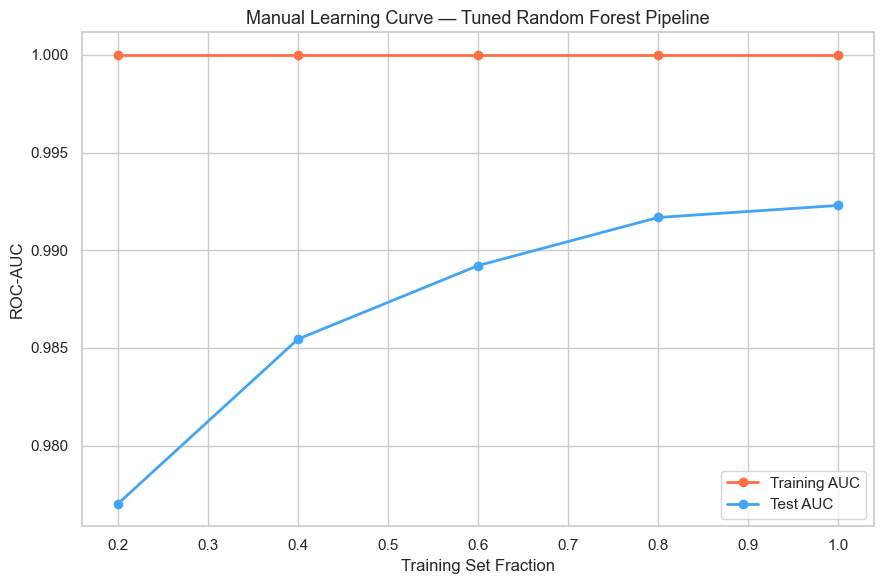

In [11]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(learning_curve_df["Training fraction"], learning_curve_df["Training AUC"],
        marker="o", label="Training AUC", color="#FF7043", linewidth=2)
ax.plot(learning_curve_df["Training fraction"], learning_curve_df["Test AUC"],
        marker="o", label="Test AUC", color="#42A5F5", linewidth=2)
ax.set_xlabel("Training Set Fraction")
ax.set_ylabel("ROC-AUC")
ax.set_title("Manual Learning Curve — Tuned Random Forest Pipeline", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

## Task 8 – Serialize Best Model

In [12]:
joblib.dump(best_pipeline, "best_model.pkl")
print("Saved: best_model.pkl")

Saved: best_model.pkl


### Reload and Predict (sanity check)

In [13]:
# Reload the saved pipeline from disk
loaded_model = joblib.load("best_model.pkl")

# Two hand-crafted test rows built explicitly from realistic training-row values.
sample_rows = pd.DataFrame([
    X_train.iloc[0].to_dict(),
    X_train.iloc[1].to_dict()
], columns=X_train.columns)

preds = loaded_model.predict(sample_rows)
probs = loaded_model.predict_proba(sample_rows)[:, 1]

print("Reloaded model predictions on 2 sample rows:")
for i in range(2):
    print(f"  Row {i+1}: predicted class = {preds[i]}, P(above-median) = {probs[i]:.4f}")

Reloaded model predictions on 2 sample rows:


  Row 1: predicted class = 1, P(above-median) = 0.9400
  Row 2: predicted class = 1, P(above-median) = 0.7550


## Task 9 – Summary Comparison Table

In [14]:
log_reg_final = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
log_reg_final.fit(X_train_scaled, y_clf_train)
log_reg_test_auc = roc_auc_score(y_clf_test, log_reg_final.predict_proba(X_test_scaled)[:, 1])

dt_test_auc = roc_auc_score(y_clf_test, dt_controlled.predict_proba(X_test_scaled)[:, 1])
rf_test_auc_final = rf_auc
gb_test_auc_final = gb_auc

best_pipeline_test_auc = roc_auc_score(y_clf_test, best_pipeline.predict_proba(X_test)[:, 1])

summary_table = pd.DataFrame([
    {"Model": "Logistic Regression", "CV Mean AUC": cv_results_df.loc[cv_results_df.Model=="Logistic Regression", "Mean AUC"].values[0],
     "CV Std AUC": cv_results_df.loc[cv_results_df.Model=="Logistic Regression", "Std AUC"].values[0], "Test AUC": log_reg_test_auc},
    {"Model": "Decision Tree (controlled)", "CV Mean AUC": cv_results_df.loc[cv_results_df.Model=="Decision Tree (controlled)", "Mean AUC"].values[0],
     "CV Std AUC": cv_results_df.loc[cv_results_df.Model=="Decision Tree (controlled)", "Std AUC"].values[0], "Test AUC": dt_test_auc},
    {"Model": "Random Forest", "CV Mean AUC": cv_results_df.loc[cv_results_df.Model=="Random Forest", "Mean AUC"].values[0],
     "CV Std AUC": cv_results_df.loc[cv_results_df.Model=="Random Forest", "Std AUC"].values[0], "Test AUC": rf_test_auc_final},
    {"Model": "Gradient Boosting", "CV Mean AUC": cv_results_df.loc[cv_results_df.Model=="Gradient Boosting", "Mean AUC"].values[0],
     "CV Std AUC": cv_results_df.loc[cv_results_df.Model=="Gradient Boosting", "Std AUC"].values[0], "Test AUC": gb_test_auc_final},
    {"Model": "Tuned RF Pipeline (GridSearchCV)", "CV Mean AUC": grid_search.best_score_,
     "CV Std AUC": best_pipeline_cv_std, "Test AUC": best_pipeline_test_auc},
])

display(summary_table)

,Model,CV Mean AUC,CV Std AUC,Test AUC
0,Logistic Regression,0.944738,0.005970,0.956863
1,Decision Tree (controlled),0.958701,0.012526,0.966825
2,Random Forest,0.989146,0.005338,0.992448
3,Gradient Boosting,0.986807,0.005228,0.988835
4,Tuned RF Pipeline (GridSearchCV),0.989818,0.004881,0.992292


---
**Part 3 analysis complete.** All ensemble models, tuning results, the saved pipeline (`best_model.pkl`), and the full comparison are interpreted in `Part 3_README.md`.